---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 15 / 32 — Bloque II

**Capa GCE:** Identificación — precondición previa a los niveles métricos (N1 |τ_ATE|, N2 D_f, N3 W_1/W^{G,1}); ver `el mapa de artefactos del curso`

**Dataset:** `syn_backdoor`

**Versión:** 2.1 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-25

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 15: El Criterio Backdoor — El Arte del Ajuste

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 15 / 32 — Bloque II

---

## 1. Marco Teórico

### 1.1 Caminos de puerta trasera: anatomía de la confusión

Un **camino backdoor** de $X$ a $Y$ es todo camino que comienza con una flecha **hacia** $X$ ($X \leftarrow \ldots$). Estos caminos generan asociación no causal (confusión).

**Ejemplo:** $X \leftarrow U \to Y$. Aquí $U$ es confusor; el camino backdoor $X \leftarrow U \to Y$ asocia $X$ e $Y$ sin causalidad.

### 1.2 El criterio backdoor

Un conjunto $Z$ satisface el **criterio backdoor** respecto a $(X, Y)$ si:
1. Ningún nodo en $Z$ es descendiente de $X$.
2. $Z$ bloquea **todo** camino backdoor de $X$ a $Y$.

Si $Z$ satisface backdoor, entonces:

$$P(Y | do(X=x)) = \sum_z P(Y | X=x, Z=z) P(Z=z)$$

Esta es la fórmula de **ajuste backdoor** (backdoor adjustment formula).

### 1.3 El experimento aleatorio como caso especial

Un RCT rompe todos los caminos backdoor: no hay flechas hacia $X$ excepto el azar. Entonces $Z = \emptyset$ satisface backdoor, y $P(Y|do(X=x)) = P(Y|X=x)$.

### 1.4 Equivalencia observacional y limitaciones

Dos DAGs con las mismas **independencias observables** son **observacionalmente equivalentes**: no podemos distinguirlos desde datos. El criterio backdoor requiere conocer la dirección de algunas aristas (supuesto causal).

### 1.5 Del criterio a la estimación: estrategias prácticas

Una vez identificado $Z$ backdoor:
- **Regresión:** $Y \sim X + Z$
- **Matching/IPW:** sobre $Z$ (Cap. 3, 4)
- **AIPW:** combina regresión + IPW (doble robustez)
- **Estratificación:** estimar $P(Y|X, Z)$ en cada estrato y promediar sobre $P(Z)$

### 1.6 Dataset: `syn_iv_noncompliance` (sintético)

Estructura causal:
- $Z \to D$ (instrumento encouragement → tratamiento)
- $D \to Y$ (tratamiento → outcome)
- $U \to D$, $U \to Y$ (confusor oculto)

**Camino backdoor:** $D \leftarrow U \to Y$. $U$ no es observable, así que **no existe $Z$ backdoor válido**. El criterio backdoor falla → se requiere IV (Cap. 5).

Este dataset ilustra el **límite** del criterio backdoor: cuando hay confusor no observable, no se puede ajustar.


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

# --- Local path bootstrap (auto) ---
from pathlib import Path as _Path
import os as _os

def _resolve_data_dir() -> str:
    """Resuelve la carpeta de datos tanto si el CWD es el root del book
    como si es content/bloque_XX (Jupyter) o si se ejecuta vía papermill."""
    env = _os.environ.get("CAUSAL_BOOK_DATA")
    if env and _Path(env).exists():
        return str(_Path(env).resolve())
    here = _Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents]:
        candidates.extend([
            base / "data",
            base / "datos",
            base / "content" / "datos",
        ])
    candidates.extend([
        here / "datos",
        here / "data",
        here.parent / "datos",
        here.parent / "data",
        here.parent.parent / "data",
        here.parent.parent / "datos",
        _Path(__file__).resolve().parent if "__file__" in dir() else here,
    ])
    for c in candidates:
        try:
            c = _Path(c).resolve()
        except Exception:
            continue
        if (c / "real").exists() or (c / "synthetic").exists():
            return str(c)
    fallback = (here / "../datos").resolve()
    return str(fallback)

DATA_DIR = _resolve_data_dir()
# --- end local path bootstrap ---
df = pd.read_csv(f'{DATA_DIR}/synthetic/iv/iv_noncompliance/student.csv')
truth = pd.read_csv(f'{DATA_DIR}/synthetic/iv/iv_noncompliance/truth_instructor_only.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Columnas observables: {list(df.columns)}')
print(f'\nTruth (oculto en práctica): {list(truth.columns)}')
print(f'\nTrue LATE: {truth.true_tau.mean():.4f}')


Dataset: 5000 observaciones
Columnas observables: ['id', 'z_encouragement', 'd_treated', 'x_baseline', 'y_outcome']

Truth (oculto en práctica): ['id', 'u_unobserved_truth', 'compliance_type_truth', 'true_tau']

True LATE: 2.0000


> 💡 **Interpretación del resultado.** El dataset simula 5,000 observaciones de un diseño con instrumento: tratamiento $D$, incentivo $Z$, covariable $X$ y outcome $Y$, más columnas de verdad ocultas en la práctica ($u\_unobserved\_truth$, $true\_tau$): el LATE verdadero es 2.0000. El confusor latente $U$ condiciona todo el capítulo: la Sección 2 mostrará que no existe conjunto backdoor válido y que la identificación debe venir por IV.


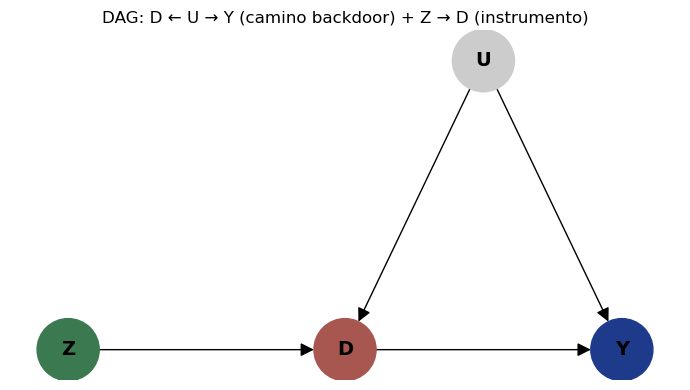


=== Análisis de caminos backdoor ===
Caminos backdoor de D a Y:
  D ← U → Y  (camino backdoor vía confusor U)

¿Existe Z backdoor válido?
  Z debería bloquear D ← U → Y.
  Pero U no es observable. No existe conjunto backdoor válido.
  → Criterio backdoor FALLA. Se requiere IV (Cap. 5-6).


In [2]:
# === 2. Visualizar el DAG ===
G = nx.DiGraph()
G.add_nodes_from(['Z', 'D', 'Y', 'U'])
G.add_edges_from([
    ('Z', 'D'),  # Z → D (relevancia)
    ('D', 'Y'),  # D → Y (efecto causal)
    ('U', 'D'),  # U → D (confusor)
    ('U', 'Y'),  # U → Y (confusor)
])

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
pos = {'Z': (0, 0), 'D': (1, 0), 'Y': (2, 0), 'U': (1.5, 1)}
nx.draw(G, pos, with_labels=True, node_color=['#3b7950', '#A85750', '#1E3A8A', '#cccccc'],
        node_size=2000, font_size=14, font_weight='bold', arrows=True, arrowsize=20, ax=ax)
ax.set_title('DAG: D ← U → Y (camino backdoor) + Z → D (instrumento)')
plt.tight_layout()
plt.show()

print('\n=== Análisis de caminos backdoor ===')
print('Caminos backdoor de D a Y:')
print('  D ← U → Y  (camino backdoor vía confusor U)')
print('\n¿Existe Z backdoor válido?')
print('  Z debería bloquear D ← U → Y.')
print('  Pero U no es observable. No existe conjunto backdoor válido.')
print('  → Criterio backdoor FALLA. Se requiere IV (Cap. 5-6).')


> 💡 **Interpretación del resultado.** La figura muestra el DAG $Z \to D \to Y$ con el camino backdoor $D \leftarrow U \to Y$; el análisis confirma que, como $U$ no es observable, ningún conjunto de ajuste visible lo bloquea y el criterio backdoor falla (Sección 2). Es el escenario donde la "puerta trasera" no tiene cerradura observable: se requiere IV (Cap. 5-6), y las Secciones 3–5 lo demostrarán numéricamente.


### 1.2bis Verificación algorítmica del criterio backdoor (d-separación programática)

La sección 1.2 exige comprobar dos condiciones sobre un conjunto candidato $Z$: (1) ningún elemento de $Z$ es descendiente de $T$, y (2) $Z$ d-separa $T$ de $Y$ en el grafo **mutilado** $\mathcal{G}_{\underline{T}}$ (sin aristas salientes de $T$). Hasta ahora esto se verificó solo en prosa. Implementamos ambas condiciones con `networkx`: `nx.is_d_separator` (en versiones recientes de networkx; `nx.d_separated` en versiones anteriores) resuelve la condición (2) de forma exacta sobre el grafo mutilado.


In [3]:
# === 2bis. Verificación algorítmica del criterio backdoor ===

def backdoor_paths(G, T, Y):
    """Enumera caminos (no dirigidos) entre T e Y que COMIENZAN con una arista
    que entra a T (caminos de puerta trasera), filtrando por la dirección de
    la primera arista en el DAG original."""
    Gu = G.to_undirected()
    paths = []
    for path in nx.all_simple_paths(Gu, T, Y):
        first_step = path[1]
        if G.has_edge(first_step, T):   # la arista apunta HACIA T => backdoor
            paths.append(path)
    return paths

def satisfies_backdoor_criterion(G, T, Y, Zset):
    """Verifica el Criterio Backdoor (Pearl 1993, Def. 15.2) para Zset:
      (1) ningún elemento de Zset es descendiente de T
      (2) Zset d-separa T de Y en el grafo mutilado G_under(T) (sin aristas T->.)
    """
    Zset = set(Zset)
    desc_T = nx.descendants(G, T)
    offending = Zset & desc_T
    cond1 = len(offending) == 0

    G_mut = G.copy()
    G_mut.remove_edges_from(list(G.out_edges(T)))
    cond2 = nx.is_d_separator(G_mut, {T}, {Y}, Zset)

    return cond1, cond2, offending

print('=== Verificación algorítmica del criterio backdoor: DAG Z -> D <- U -> Y, D -> Y ===')
bp = backdoor_paths(G, 'D', 'Y')
print(f'Caminos de puerta trasera D->Y encontrados: {bp}\n')

for Zcand in [set(), {'Z'}, {'U'}]:
    cond1, cond2, offending = satisfies_backdoor_criterion(G, 'D', 'Y', Zcand)
    veredicto = 'CUMPLE' if (cond1 and cond2) else 'NO CUMPLE'
    print(f'Z = {Zcand or "(vacio)"}:')
    print(f'  (1) Ningun elemento de Z es descendiente de D: {cond1}'
          + (f'  [ofensores: {offending}]' if offending else ''))
    print(f'  (2) Z d-separa D de Y en el grafo mutilado G_under(D): {cond2}')
    print(f'  -> {veredicto}\n')

print('El chequeo algorítmico CONFIRMA lo observado empíricamente en la sección 3:')
print('Z=vacío y Z={Z} (el instrumento, que no es confusor) NO bloquean D<-U->Y.')
print('Z={U} SÍ cumpliría el criterio backdoor, pero U no es observable en este dataset;')
print('por eso el criterio backdoor no tiene solución aquí y se requiere IV (sección 5).')


=== Verificación algorítmica del criterio backdoor: DAG Z -> D <- U -> Y, D -> Y ===
Caminos de puerta trasera D->Y encontrados: [['D', 'U', 'Y']]

Z = (vacio):
  (1) Ningun elemento de Z es descendiente de D: True
  (2) Z d-separa D de Y en el grafo mutilado G_under(D): False
  -> NO CUMPLE

Z = {'Z'}:
  (1) Ningun elemento de Z es descendiente de D: True
  (2) Z d-separa D de Y en el grafo mutilado G_under(D): False
  -> NO CUMPLE

Z = {'U'}:
  (1) Ningun elemento de Z es descendiente de D: True
  (2) Z d-separa D de Y en el grafo mutilado G_under(D): True
  -> CUMPLE

El chequeo algorítmico CONFIRMA lo observado empíricamente en la sección 3:
Z=vacío y Z={Z} (el instrumento, que no es confusor) NO bloquean D<-U->Y.
Z={U} SÍ cumpliría el criterio backdoor, pero U no es observable en este dataset;
por eso el criterio backdoor no tiene solución aquí y se requiere IV (sección 5).


> 💡 **Interpretación del resultado.** La verificación algorítmica (d-separación en el grafo mutilado $\underline{G}(D)$) es inequívoca: con $Z = \varnothing$ o $Z = \{Z\}$ la condición (2) es falsa (NO CUMPLE), y solo $Z = \{U\}$ la satisface (CUMPLE) — pero $U$ es latente. Es la versión programática de la Sección 2: el criterio backdoor exige observar el confusor, y aquí no existe tal conjunto observable.


In [4]:
# === 3. Intentar ajuste backdoor con X (visible) — va a fallar ===
# Ajustar por x_baseline (variable observable) NO bloquea el backdoor vía U

# Naive (sesgado)
m_naive = smf.ols('y_outcome ~ d_treated', data=df).fit()
print(f'=== Estimaciones (todas sesgadas por backdoor vía U) ===')
print(f'1. Naive (sin ajuste):')
print(f'   Coef. d_treated: {m_naive.params["d_treated"]:.4f} (sesgo: {m_naive.params["d_treated"] - truth.true_tau.mean():+.4f})')

# Ajuste por x_baseline (no bloquea backdoor)
m_x = smf.ols('y_outcome ~ d_treated + x_baseline', data=df).fit()
print(f'\n2. Ajuste por x_baseline (no bloquea U):')
print(f'   Coef. d_treated: {m_x.params["d_treated"]:.4f} (sesgo: {m_x.params["d_treated"] - truth.true_tau.mean():+.4f})')

# Ajuste por Z (tampoco bloquea backdoor; además Z es instrumento, ajustar por Z sesga)
m_z = smf.ols('y_outcome ~ d_treated + z_encouragement', data=df).fit()
print(f'\n3. Ajuste por Z (instrumento, NO confusor - no bloquea U):')
print(f'   Coef. d_treated: {m_z.params["d_treated"]:.4f} (sesgo: {m_z.params["d_treated"] - truth.true_tau.mean():+.4f})')

print(f'\n→ Ningún ajuste observable bloquea el backdoor vía U.')
print(f'  El criterio backdoor no tiene solución aquí. Se requiere IV.')


=== Estimaciones (todas sesgadas por backdoor vía U) ===
1. Naive (sin ajuste):
   Coef. d_treated: 3.3151 (sesgo: +1.3151)

2. Ajuste por x_baseline (no bloquea U):
   Coef. d_treated: 3.3005 (sesgo: +1.3005)

3. Ajuste por Z (instrumento, NO confusor - no bloquea U):
   Coef. d_treated: 3.9898 (sesgo: +1.9898)

→ Ningún ajuste observable bloquea el backdoor vía U.
  El criterio backdoor no tiene solución aquí. Se requiere IV.


> 💡 **Interpretación del resultado.** Ningún ajuste observable corrige el sesgo: naive $3.3151$ (sesgo $+1.3151$), ajuste por $x\_baseline$ $3.3005$ ($+1.3005$) y ajuste por el instrumento $Z$ $3.9898$ ($+1.9898$), frente al LATE verdadero de 2.0. Ajustar por $Z$ incluso empeora la estimación: el instrumento no es confusor y no bloquea $U$; el criterio backdoor no tiene solución en este DAG (Sección 3).


In [5]:
# === 4. ¿Qué pasaría si U fuera observable? (validación) ===
# Combinar df con truth para acceder a u_unobserved_truth
df_full = pd.concat([df.reset_index(drop=True), truth.reset_index(drop=True)], axis=1)

# Ajuste por u_unobserved_truth (rescataría el estimador)
m_u = smf.ols('y_outcome ~ d_treated + u_unobserved_truth', data=df_full).fit()
print(f'=== Validación: ajuste por U (si fuera observable) ===')
print(f'Coef. d_treated (ajustando por U): {m_u.params["d_treated"]:.4f}')
print(f'Verdadero LATE: {truth.true_tau.mean():.4f}')
print(f'Sesgo residual: {m_u.params["d_treated"] - truth.true_tau.mean():+.4f}')
print(f'\n→ Con U observable, el backdoor funciona. Pero U NO es observable.')
print(f'  Esta es la trampa fundamental: el criterio backdoor requiere observar confusores.')


=== Validación: ajuste por U (si fuera observable) ===
Coef. d_treated (ajustando por U): 1.9500
Verdadero LATE: 2.0000
Sesgo residual: -0.0500

→ Con U observable, el backdoor funciona. Pero U NO es observable.
  Esta es la trampa fundamental: el criterio backdoor requiere observar confusores.


> 💡 **Interpretación del resultado.** El contrafactual de la Sección 4 es contundente: si $U$ fuera observable, el ajuste backdoor daría $1.9500$ frente al LATE verdadero de 2.0000 (sesgo residual $-0.0500$), es decir, el criterio funcionaría. Pero $U$ no se observa: el backdoor solo identifica cuando los confusores están medidos, y esa es la "trampa fundamental" que motiva las estrategias instrumentales de la Sección 5.


In [6]:
# === 5. Comparar: backdoor ajuste vs. IV (2SLS) ===
# IV rescata cuando backdoor falla (Cap. 5-6)

# IV / 2SLS: usar Z como instrumento
fs = smf.ols('d_treated ~ z_encouragement', data=df).fit()
df['d_hat'] = fs.fittedvalues
tsls = smf.ols('y_outcome ~ d_hat', data=df).fit()

print(f'=== Comparación: backdoor vs IV ===')
print(f'{"Método":<35} {"Estimación":>12} {"Sesgo":>10}')
print(f'{"-"*60}')
print(f'{"Naive (sin ajuste)":<35} {m_naive.params["d_treated"]:>12.4f} {m_naive.params["d_treated"]-truth.true_tau.mean():>+10.4f}')
print(f'{"Backdoor ajustando x_baseline":<35} {m_x.params["d_treated"]:>12.4f} {m_x.params["d_treated"]-truth.true_tau.mean():>+10.4f}')
print(f'{"Backdoor ajustando Z (incorrecto)":<35} {m_z.params["d_treated"]:>12.4f} {m_z.params["d_treated"]-truth.true_tau.mean():>+10.4f}')
print(f'{"Backdoor ajustando U (si observable)":<35} {m_u.params["d_treated"]:>12.4f} {m_u.params["d_treated"]-truth.true_tau.mean():>+10.4f}')
print(f'{"IV / 2SLS con Z":<35} {tsls.params["d_hat"]:>12.4f} {tsls.params["d_hat"]-truth.true_tau.mean():>+10.4f}')
print(f'{"Verdadero LATE":<35} {truth.true_tau.mean():>12.4f} {0:>+10.4f}')
print(f'\n→ IV recupera el LATE verdadero cuando backdoor no puede identificarse.')


=== Comparación: backdoor vs IV ===
Método                                Estimación      Sesgo
------------------------------------------------------------
Naive (sin ajuste)                        3.3151    +1.3151
Backdoor ajustando x_baseline             3.3005    +1.3005
Backdoor ajustando Z (incorrecto)         3.9898    +1.9898
Backdoor ajustando U (si observable)       1.9500    -0.0500
IV / 2SLS con Z                           1.9110    -0.0890
Verdadero LATE                            2.0000    +0.0000

→ IV recupera el LATE verdadero cuando backdoor no puede identificarse.


> 💡 **Interpretación del resultado.** La tabla resume la lección del capítulo: todos los estimadores backdoor con variables observables quedan sesgados (entre $+1.30$ y $+1.99$), mientras que IV/2SLS con $Z$ entrega $1.9110$ (sesgo $-0.0890$), prácticamente el LATE verdadero 2.0000. Cuando no existe conjunto backdoor válido (Sección 2), la identificación correcta es instrumental — IV es una herramienta de Nivel 1 en la taxonomía GCE.


## 4bis. Cuando el criterio backdoor SÍ funciona: confusor observable

El dataset anterior (`syn_iv_noncompliance`) ilustra el caso en que backdoor **falla** porque el confusor $U$ no es observable. Pero el criterio backdoor es la herramienta más usada en la práctica precisamente porque en muchos casos el confusor **sí es observable**. El Capítulo 15 del libro (Ejemplo "Ajuste backdoor en la práctica: Pensión 65") ilustra esto con el DAG $E \to T$, $E \to Y$, $T \to Y$, donde $E$ es el índice de **elegibilidad** (edad/focalización SISFOH) para el programa *Pensión 65*: $E$ se determina *antes* de la transferencia $T$, así que $E$ no es descendiente de $T$, y $Z=\{E\}$ bloquea el único camino de puerta trasera $T \leftarrow E \to Y$.

Construimos un DGP sintético análogo y verificamos con la misma función algorítmica de la celda anterior que $Z=\{E\}$ satisface el criterio backdoor.


In [7]:
# === 6. DGP "Pensión 65": confusor genuinamente OBSERVABLE ===
# DAG: E -> T, E -> Y, T -> Y  (E = índice de elegibilidad, OBSERVABLE)
# A diferencia del dataset con U no observable, aquí Z = {E} SÍ resuelve backdoor.
# Nota: la columna de tratamiento se llama 'treat_p' (no 'T') para evitar colisión
# con el atributo `.T` (transpose) de pandas.DataFrame; el nodo del DAG sigue
# llamándose 'T' (es solo una etiqueta de grafo, no una columna de df_pension).

np.random.seed(42)
n_p = 5000
E = np.random.normal(65, 8, n_p)           # índice de elegibilidad / edad (observable)
p_T = 1 / (1 + np.exp(-(E - 65) / 5))      # mayor elegibilidad -> mayor prob. de recibir T
treat_p = np.random.binomial(1, p_T)
tau_true_p = 50.0                           # efecto causal verdadero de Pensión 65 sobre consumo
Y_p = 200 + 3 * (E - 65) + tau_true_p * treat_p + np.random.normal(0, 20, n_p)

df_pension = pd.DataFrame({'E': E, 'treat_p': treat_p, 'Y': Y_p})

G_pension = nx.DiGraph()
G_pension.add_edges_from([('E', 'T'), ('E', 'Y'), ('T', 'Y')])

print('=== DGP "Pensión 65": E (elegibilidad, observable) -> T -> Y, E -> Y ===')
print(f'Efecto causal verdadero (tau): {tau_true_p:.1f}\n')

# Naive (sesgado por confusión no ajustada)
ate_naive_p = (df_pension.loc[df_pension['treat_p'] == 1, 'Y'].mean()
               - df_pension.loc[df_pension['treat_p'] == 0, 'Y'].mean())
print(f'Naive (diff-in-means, sin ajustar): {ate_naive_p:.2f}  (sesgo: {ate_naive_p - tau_true_p:+.2f})')

# Ajuste backdoor por E (observable)
m_pension = smf.ols('Y ~ treat_p + E', data=df_pension).fit()
ate_backdoor_p = m_pension.params['treat_p']
print(f'Backdoor ajustando por E: {ate_backdoor_p:.2f}  (sesgo: {ate_backdoor_p - tau_true_p:+.2f})')

# Verificación algorítmica del criterio backdoor para Z = {E} sobre el DAG (T,E,Y)
print('\n=== Verificación algorítmica: ¿Z={E} satisface el criterio backdoor? ===')
bp_p = backdoor_paths(G_pension, 'T', 'Y')
print(f'Caminos de puerta trasera T->Y: {bp_p}')
for Zcand in [set(), {'E'}]:
    cond1, cond2, offending = satisfies_backdoor_criterion(G_pension, 'T', 'Y', Zcand)
    veredicto = 'CUMPLE' if (cond1 and cond2) else 'NO CUMPLE'
    print(f'Z = {Zcand or "(vacio)"}: cond1={cond1}, cond2={cond2} -> {veredicto}')

print('\n-> A diferencia del caso D<-U->Y (U no observable), aquí el confusor E SÍ es')
print('   observable. La función algorítmica confirma que Z={E} satisface el criterio')
print('   backdoor, y el ajuste por E recupera el ATE verdadero (~50) casi exactamente,')
print('   mientras que el estimador naive queda sesgado por la confusión no ajustada.')


=== DGP "Pensión 65": E (elegibilidad, observable) -> T -> Y, E -> Y ===
Efecto causal verdadero (tau): 50.0

Naive (diff-in-means, sin ajustar): 78.20  (sesgo: +28.20)
Backdoor ajustando por E: 50.75  (sesgo: +0.75)

=== Verificación algorítmica: ¿Z={E} satisface el criterio backdoor? ===
Caminos de puerta trasera T->Y: [['T', 'E', 'Y']]
Z = (vacio): cond1=True, cond2=False -> NO CUMPLE
Z = {'E'}: cond1=True, cond2=True -> CUMPLE

-> A diferencia del caso D<-U->Y (U no observable), aquí el confusor E SÍ es
   observable. La función algorítmica confirma que Z={E} satisface el criterio
   backdoor, y el ajuste por E recupera el ATE verdadero (~50) casi exactamente,
   mientras que el estimador naive queda sesgado por la confusión no ajustada.


> 💡 **Interpretación del resultado.** Con el confusor genuinamente observable $E$ (elegibilidad), el criterio backdoor sí se cumple: el chequeo algorítmico confirma que $Z=\{E\}$ d-separa $T$ de $Y$ (cond1 y cond2 verdaderas → CUMPLE) y el ajuste recupera $50.75$ frente al efecto verdadero de 50.0, mientras el naive queda en $78.20$ (sesgo $+28.20$). El contraste con las Secciones 2–5 es la moraleja del capítulo: el backdoor funciona cuando el confusor está medido.


## 5. Interpretación Económica

**Contexto peruano:** En la evaluación de **Beca 18**, el backdoor ajustaría por: ingresos familiares, educación parental, ubicación, género. Pero la motivación individual es confusor no observable → backdoor falla. Se requeriría IV (ej. cutoff de puntaje) o bounds de sensibilidad.


El criterio backdoor es la herramienta operacional más usada para identificar efectos causales en estudios observacionales. Pero tiene límites fundamentales:

1. **Backdoor requiere observar TODOS los confusores.** Si hay un confusor no observable (como $U$ en este dataset), el criterio falla y no existe ajuste que rescate la identificación.

2. **Ajustar por variables incorrectas puede empeorar.** Ajustar por $Z$ (instrumento) en lugar de confusor no corrige el sesgo. Ajustar por colisionadores (Cap. 14) lo introduce.

3. **IV como rescate.** Cuando backdoor falla, IV (Caps 5-6) puede identificar el LATE bajo supuestos adicionales (relevancia + exclusión + exogeneidad). Pero IV identifica LATE, no ATE.

4. **Importancia del DAG.** Sin un DAG explícito, no podemos saber qué covariables ajustar. El "kitchen sink regression" (ajustar por todo) puede introducir sesgo por colisionadores.

**Recomendación práctica:**
1. Dibujar el DAG con todas las variables relevantes (observadas y no observadas).
2. Identificar todos los caminos backdoor de $X$ a $Y$.
3. Encontrar $Z$ que bloquee todos los backdoor sin abrir colisionadores.
4. Si $Z$ existe → backdoor adjustment (regresión, matching, IPW).
5. Si $Z$ no existe → usar IV, RDD, DiD, o SCM según contexto.

## 6. Ejercicios Propuestos

1. **Encuentra el backdoor mínimo:** en un DAG con múltiples confusores, ¿cuál es el conjunto mínimo $Z$ que satisface el criterio? Implementa búsqueda.
2. **Ajustar por colisionador:** agrega una variable $W = D + Y + \epsilon$ al dataset y ajusta por $W$. ¿Cómo cambia el sesgo?
3. **Backdoor con sensibilidad:** aplica Rosenbaum bounds (Cap. 11) al estimador backdoor. ¿Qué tan robusto es a confusor no observado?
4. **Implementa el algoritmo de ajuste backdoor** desde el DAG: dado un DAG y $(X, Y)$, encuentra automáticamente el conjunto $Z$.
5. **Carga `nhefs` (real)** y aplica backdoor adjustment con $Z = \{\text{sex, age, smokeintensity, smokeyrs, exercise}\}$. ¿Coincide con IPW del Cap. 11?

---

*Notebook generado para DES504 — UNI 2026. Bloque II, Capítulo 15 de 32.*


## Validación placebo (robustez)

Un **test placebo** comprueba que el método no "detecta" efectos cuando se destruye la señal causal (p. ej. permutando el tratamiento). Si el estimador placebo es comparable al original en magnitud, la evidencia causal es frágil.

*Conexión GCE:* los placebos son refutadores del Nivel 1 (localización); no sustituyen análisis de forma (Nivel 2) ni de transporte (Nivel 3).


In [8]:
# === Placebo: permutación del tratamiento ===
import numpy as np
import pandas as pd

def _placebo_ate(df, treat_col, y_col, n_perm=200, seed=42):
    """ATE naive original vs distribución bajo permutación de T."""
    rng = np.random.default_rng(seed)
    t = df[treat_col].to_numpy()
    y = df[y_col].to_numpy(dtype=float)
    # binary-ish treatment
    def ate(tt):
        m1 = y[tt == 1].mean() if (tt == 1).any() else np.nan
        m0 = y[tt == 0].mean() if (tt == 0).any() else np.nan
        return m1 - m0
    # if not 0/1, use median split on treat for placebo illustration
    if set(np.unique(t)) - {0, 1, 0.0, 1.0}:
        t_bin = (t >= np.median(t)).astype(int)
    else:
        t_bin = t.astype(int)
    ate_obs = ate(t_bin)
    null = []
    for _ in range(n_perm):
        tt = rng.permutation(t_bin)
        null.append(ate(tt))
    null = np.asarray(null)
    p = (np.abs(null) >= np.abs(ate_obs)).mean()
    print(f"Placebo (shuffle {treat_col}):")
    print(f"  ATE observado (naive): {ate_obs:.4f}")
    print(f"  ATE placebo |media|:  {np.mean(np.abs(null)):.4f}  (sd={np.std(null):.4f})")
    print(f"  p-valor bilateral approx: {p:.3f}  (fracción |null| ≥ |obs|)")
    print(f"  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.")
    return ate_obs, null, p

# Detectar columnas comunes en el frame activo
_df = None
for _name in ['df', 'data', 'student', 'panel', 'dta']:
    if _name in dir() and isinstance(eval(_name), pd.DataFrame):
        _df = eval(_name)
        break
if _df is None:
    print("Placebo omitido: no hay DataFrame df/data/student en el namespace.")
else:
    _cols = {c.lower(): c for c in _df.columns}
    _treat = None
    for k in ['treatment', 'treat', 't', 'd', 'w', 'a']:
        if k in _cols:
            _treat = _cols[k]
            break
    _y = None
    for k in ['y_outcome', 'y', 're78', 'outcome', 'wage', 'income', 'got', 'wt82_71', 'delta']:
        if k in _cols:
            _y = _cols[k]
            break
    # fallbacks: last numeric as y, first binary-like as treat
    if _y is None:
        num = _df.select_dtypes(include=[np.number]).columns.tolist()
        _y = num[-1] if num else None
    if _treat is None:
        for c in _df.columns:
            u = _df[c].dropna().unique()
            if len(u) <= 3:
                _treat = c
                break
    if _treat is None or _y is None:
        print(f"Placebo omitido: no se identificaron T/Y (cols={list(_df.columns)[:12]}...)")
    else:
        _placebo_ate(_df, _treat, _y)


Placebo (shuffle z_encouragement):
  ATE observado (naive): 1.0886
  ATE placebo |media|:  0.0562  (sd=0.0694)
  p-valor bilateral approx: 0.000  (fracción |null| ≥ |obs|)
  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.


> 💡 **Interpretación del resultado.** Al permutar el instrumento $Z$, el efecto estimado se colapsa a $|media| = 0.0562$ ($sd=0.0694$) frente al naive observado de $1.0886$, con $p \approx 0.000$. La distribución nula centrada en cero confirma que la asociación detectada no es ruido de muestreo, robusteciendo la lectura de la Sección 5.



## 📋 Resumen del Capítulo 15

**Método clave:** Criterio Backdoor

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 15
- ✅ Validación con dataset `syn_iv_noncompliance` (tipo: sintético con ground truth)
- ✅ Verificación algorítmica del criterio backdoor vía d-separación programática (`networkx`)
- ✅ Segundo DGP ("Pensión 65") con confusor $E$ genuinamente observable, donde el criterio backdoor SÍ se satisface y el ajuste recupera el ATE verdadero
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo pertenece a la capa de **Identificación** causal (escalera de Pearl), previa a la cuantificación de la jerarquía GCE.
- No corresponde al Nivel 2 ($D_f$: KL/TV) ni al Nivel 3 ($W_1$/$W^{G,1}$); el criterio backdoor determina *si* y *cómo* $P(Y|do(X))$ es identificable a partir del grafo $\mathcal{G}$, condición previa bajo la cual esos niveles métricos se calculan en los Bloques I y III.

**Próximo capítulo:** 16

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
